# E-Commerce Marketplace Analysis — Wish Summer Products

Exploratory analysis of **1,573 product listings** (43 variables) scraped from the Wish marketplace for the keyword *summer*. The goal: understand **what actually drives a product to sell** — price, customer trust (ratings & reviews), merchant credibility, or promotional mechanisms (ad boosts, urgency banners, badges) — and turn that into actionable marketing and product-discovery insight.

## Import libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display & style settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Load the dataset

In [2]:
df = pd.read_csv('summer.csv')
print('Dataset shape:', df.shape)
df.head(3)

Dataset shape: (1573, 43)


,title,title_orig,price,retail_price,currency_buyer,units_sold,uses_ad_boosts,rating,rating_count,rating_five_count,rating_four_count,rating_three_count,rating_two_count,rating_one_count,badges_count,badge_local_product,badge_product_quality,badge_fast_shipping,tags,product_color,product_variation_size_id,product_variation_inventory,shipping_option_name,shipping_option_price,shipping_is_express,countries_shipped_to,inventory_total,has_urgency_banner,urgency_text,origin_country,merchant_title,merchant_name,merchant_info_subtitle,merchant_rating_count,merchant_rating,merchant_id,merchant_has_profile_picture,merchant_profile_picture,product_url,product_picture,product_id,theme,crawl_month
0,2020 Summer Vintage Flamingo Print Pajamas Set Casual Loose T Shirt Top And Elastic Shorts Women Sleepwear Night Wear Loungewear Sets,2020 Summer Vintage Flamingo Print Pajamas Set Casual Loose T Shirt Top And Elastic Shorts Women Sleepwear Night Wear Loungewear Sets,16.00,14,EUR,100,0,3.76,54,26.00,8.00,10.00,1.00,9.00,0,0,0,0,"Summer,Fashion,womenunderwearsuit,printedpajamasset,womencasualshort,Women's Fashion,flamingo,loungewearset,Casual,Shirt,casualsleepwear,Shorts,flamingotshirt,Elastic,Vintage,Tops,tshirtandshortsset,Women,Sleepwear,Print,womenpajamasset,womennightwear,Pajamas,womensleepwearset",white,M,50,Livraison standard,4,0,34,50,1.00,Quantité limitée !,CN,zgrdejia,zgrdejia,(568 notes),568,4.13,595097d6a26f6e070cb878d1,0,NaN,https://www.wish.com/c/5e9ae51d43d6a96e303acdb0,https://contestimg.wish.com/api/webimage/5e9ae51d43d6a96e303acdb0-medium.jpg,5e9ae51d43d6a96e303acdb0,summer,2020-08
1,SSHOUSE Summer Casual Sleeveless Soirée Party Soirée sans manches Vêtements de plage sexy Mini robe femme wshC1612242400387A21,Women's Casual Summer Sleeveless Sexy Mini Dress,8.00,22,EUR,20000,1,3.45,6135,2269.00,1027.00,1118.00,644.00,1077.00,0,0,0,0,"Mini,womens dresses,Summer,Patchwork,fashion dress,Dress,Mini dress,Women's Fashion,Women S Clothing,backless,party,summer dresses,sleeveless,sexy,Casual",green,XS,50,Livraison standard,2,0,41,50,1.00,Quantité limitée !,CN,SaraHouse,sarahouse,"83 % avis positifs (17,752 notes)",17752,3.90,56458aa03a698c35c9050988,0,NaN,https://www.wish.com/c/58940d436a0d3d5da4e95a38,https://contestimg.wish.com/api/webimage/58940d436a0d3d5da4e95a38-medium.jpg,58940d436a0d3d5da4e95a38,summer,2020-08
2,2020 Nouvelle Arrivée Femmes Printemps et Été Plage Porter Longue Mince Cardigan Ouvert Avant Kimono Vert Feuille Imprimé En Mousseline de Soie Cardigan S-5XL,2020 New Arrival Women Spring and Summer Beach Wear Long Thin Cardigan Open Front Kimono Green Leaf Printed Chiffon Cardigan S-5XL,8.00,43,EUR,100,0,3.57,14,5.00,4.00,2.00,0.00,3.00,0,0,0,0,"Summer,cardigan,women beachwear,chiffon,Sexy women,Coat,summercardigan,openfront,short sleeves,Swimsuit,Women's Fashion,leaf,Green,printed,Spring,longcardigan,Women,Beach,kimono",leopardprint,XS,1,Livraison standard,3,0,36,50,1.00,Quantité limitée !,CN,hxt520,hxt520,86 % avis positifs (295 notes),295,3.99,5d464a1ffdf7bc44ee933c65,0,NaN,https://www.wish.com/c/5ea10e2c617580260d55310a,https://contestimg.wish.com/api/webimage/5ea10e2c617580260d55310a-medium.jpg,5ea10e2c617580260d55310a,summer,2020-08


## Initial inspection

In [3]:
df.columns

Index(['title', 'title_orig', 'price', 'retail_price', 'currency_buyer',
       'units_sold', 'uses_ad_boosts', 'rating', 'rating_count',
       'rating_five_count', 'rating_four_count', 'rating_three_count',
       'rating_two_count', 'rating_one_count', 'badges_count',
       'badge_local_product', 'badge_product_quality', 'badge_fast_shipping',
       'tags', 'product_color', 'product_variation_size_id',
       'product_variation_inventory', 'shipping_option_name',
       'shipping_option_price', 'shipping_is_express', 'countries_shipped_to',
       'inventory_total', 'has_urgency_banner', 'urgency_text',
       'origin_country', 'merchant_title', 'merchant_name',
       'merchant_info_subtitle', 'merchant_rating_count', 'merchant_rating',
       'merchant_id', 'merchant_has_profile_picture',
       'merchant_profile_picture', 'product_url', 'product_picture',
       'product_id', 'theme', 'crawl_month'],
      dtype='object')

In [4]:
df.describe()

,price,retail_price,units_sold,uses_ad_boosts,rating,rating_count,rating_five_count,rating_four_count,rating_three_count,rating_two_count,rating_one_count,badges_count,badge_local_product,badge_product_quality,badge_fast_shipping,product_variation_inventory,shipping_option_price,shipping_is_express,countries_shipped_to,inventory_total,has_urgency_banner,merchant_rating_count,merchant_rating,merchant_has_profile_picture
count,1573.00,1573.00,1573.00,1573.00,1573.00,1573.00,1528.00,1528.00,1528.00,1528.00,1528.00,1573.00,1573.00,1573.00,1573.00,1573.00,1573.00,1573.00,1573.00,1573.00,473.00,1573.00,1573.00,1573.00
mean,8.33,23.29,4339.01,0.43,3.82,889.66,442.26,179.60,134.55,63.71,95.74,0.11,0.02,0.07,0.01,33.08,2.35,0.00,40.46,49.82,1.00,26495.83,4.03,0.14
std,3.93,30.36,9356.54,0.50,0.52,1983.93,980.20,400.52,311.69,151.34,214.08,0.34,0.13,0.26,0.11,21.35,1.02,0.05,20.30,2.56,0.00,78474.46,0.20,0.35
min,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,6.00,1.00,1.00,0.00,2.33,0.00
25%,5.81,7.00,100.00,0.00,3.55,24.00,12.00,5.00,4.00,2.00,4.00,0.00,0.00,0.00,0.00,6.00,2.00,0.00,31.00,50.00,1.00,1987.00,3.92,0.00
50%,8.00,10.00,1000.00,0.00,3.85,150.00,79.00,31.50,24.00,11.00,20.00,0.00,0.00,0.00,0.00,50.00,2.00,0.00,40.00,50.00,1.00,7936.00,4.04,0.00
75%,11.00,26.00,5000.00,1.00,4.11,855.00,413.50,168.25,129.25,62.00,94.00,0.00,0.00,0.00,0.00,50.00,3.00,0.00,43.00,50.00,1.00,24564.00,4.16,0.00
max,49.00,252.00,100000.00,1.00,5.00,20744.00,11548.00,4152.00,3658.00,2003.00,2789.00,3.00,1.00,1.00,1.00,50.00,12.00,1.00,140.00,50.00,1.00,2174765.00,5.00,1.00


## Data quality

Duplicate listings and missing values before any analysis.

In [5]:
# Duplicate products
df.duplicated(subset='product_id').sum()

np.int64(232)

In [6]:
# Missing values (top 10)
df.isnull().sum().sort_values(ascending=False).head(10)

,0
merchant_profile_picture,1347
has_urgency_banner,1100
urgency_text,1100
rating_two_count,45
rating_five_count,45
rating_four_count,45
rating_three_count,45
rating_one_count,45
product_color,41
origin_country,17


## Price sanity check

In [7]:
df[['price', 'retail_price', 'shipping_option_price']].describe()

,price,retail_price,shipping_option_price
count,1573.00,1573.00,1573.00
mean,8.33,23.29,2.35
std,3.93,30.36,1.02
min,1.00,1.00,1.00
25%,5.81,7.00,2.00
50%,8.00,10.00,2.00
75%,11.00,26.00,3.00
max,49.00,252.00,12.00


## Sales distribution

`units_sold` is extremely skewed — a few products sell in huge volumes while most sell little.

In [8]:
df['units_sold'].describe()

,units_sold
count,1573.00
mean,4339.01
std,9356.54
min,1.00
25%,100.00
50%,1000.00
75%,5000.00
max,100000.00


In [9]:
# Does price relate to sales? (Pearson)
df[['price', 'units_sold']].corr()

,price,units_sold
price,1.00,-0.02
units_sold,-0.02,1.00


## Sales Performance Index (SPI)

To compare products fairly across very different scales, I build a single **Sales Performance Index** from three normalized signals — sales volume, price and rating:

$$SPI = \frac{units\_sold}{\max(units\_sold)} \times \frac{price}{\max(price)} \times \frac{rating}{5}$$

In [10]:
# Creating the Sales Performance Index
df['sales_norm']  = df['units_sold'] / df['units_sold'].max()
df['price_norm']  = df['price'] / df['price'].max()
df['rating_norm'] = df['rating'] / 5

df['SPI'] = df['sales_norm'] * df['price_norm'] * df['rating_norm']

In [11]:
# Top products by SPI
df_spi_ranked = df.sort_values(by='SPI', ascending=False)
df_spi_ranked[['title_orig', 'price', 'units_sold', 'rating', 'SPI']].head(10)

,title_orig,price,units_sold,rating,SPI
214,New Aeeival Women Clothing Long Sleeve Autumn Winter Ball Gown Dress Slim Fit Patchwork Casual Lace Dress Vestido De Renda,8.00,100000,3.76,0.12
401,Women Lace Beach Boho Maxi Sundress Sleeveless Long Dress Party Holiday Strapless Dresses,15.00,50000,3.94,0.12
1018,Women Lace Short Sleeve Long Tops Blouse Shirt Ladies Beach BOHO Mini Dress 6-16,7.00,100000,3.82,0.11
92,Women Stretchy Camisole Spaghetti Strap Long Tank Top Slip Mini Dress 4Color SIZE XXL is available Now,5.77,100000,4.10,0.10
1028,Women's Striped Double Up Tankini Top,11.00,50000,3.91,0.09
1168,Women's Summer Sexy Sleeveless Turtleneck Mini Dress,5.67,100000,3.53,0.08
251,Womens Summer Red White and Blue Chiffon Short-Sleeve T-Shirt,5.00,100000,3.98,0.08
40,Sexy Women Casual Striped T-shirt Long Tops Blouse Kaftan Beach Shirt Mini Dress,9.00,50000,4.26,0.08
17,2018 New Fashion Women's Tops Sexy Strappy Sleeveless Lace Crop Tops,5.00,100000,3.83,0.08
952,Hot Latest Sexy Bikini Women Fashion Swimming Suit Beach Bikini with Bracket Gather NOR,9.00,50000,3.83,0.07


In [12]:
# SPI distribution
df['SPI'].describe()

,SPI
count,1573.00
mean,0.01
std,0.01
min,0.00
25%,0.00
50%,0.00
75%,0.01
max,0.12


## What drives product success? — correlation

Which marketplace signals move together with sales? A correlation heatmap over the numeric signals (price, ratings, **review volume**, ad boosts, badges, merchant credibility).

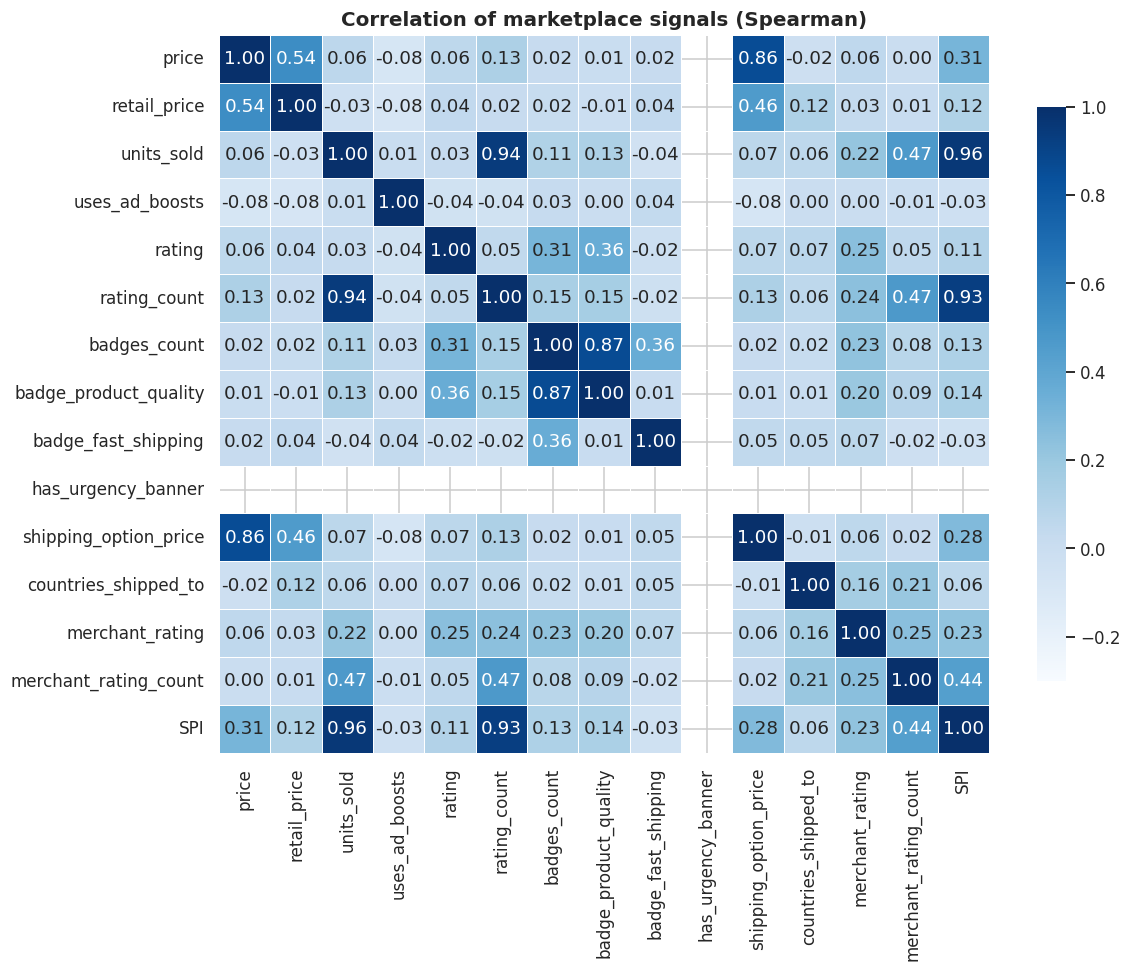

In [13]:
signals = ['price','retail_price','units_sold','uses_ad_boosts','rating','rating_count',
           'badges_count','badge_product_quality','badge_fast_shipping','has_urgency_banner',
           'shipping_option_price','countries_shipped_to','merchant_rating','merchant_rating_count','SPI']
corr = df[signals].corr(method='spearman')
plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-0.3, vmax=1,
            cbar_kws={'shrink':0.8}, linewidths=0.4)
plt.title('Correlation of marketplace signals (Spearman)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

**Read-out:** sales (`units_sold`) move most with **`rating_count`** — the *number of reviews* — far more than with `rating` (star average) or `price`. Social proof, not being cheapest, is what tracks sales.

## The trust curve — reviews vs. sales

Plotting review volume against units sold (log–log) shows the relationship directly.

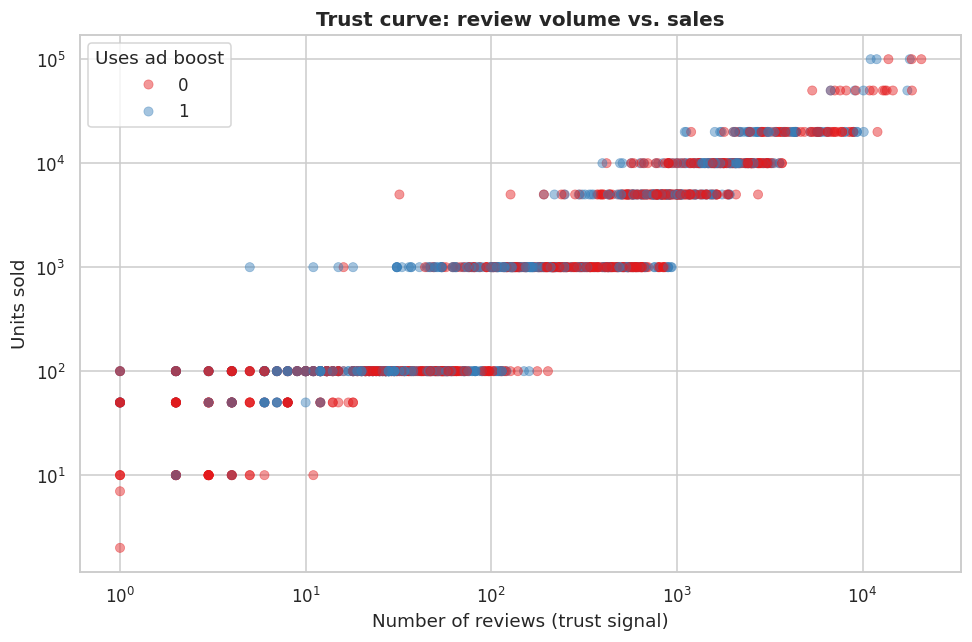

In [14]:
d = df[(df['rating_count']>0) & (df['units_sold']>0)]
plt.figure(figsize=(9,6))
sns.scatterplot(data=d, x='rating_count', y='units_sold',
                hue='uses_ad_boosts', alpha=0.45, edgecolor=None, palette='Set1')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Number of reviews (trust signal)'); plt.ylabel('Units sold')
plt.title('Trust curve: review volume vs. sales', fontsize=13, weight='bold')
plt.legend(title='Uses ad boost')
plt.tight_layout(); plt.show()

**Read-out:** sales rise steadily with review volume — and ad-boosted products (orange) are spread across the whole range, i.e. paid boosts don't separate winners from losers. **Trust scales sales; ads don't guarantee them.**

## Price is not the driver

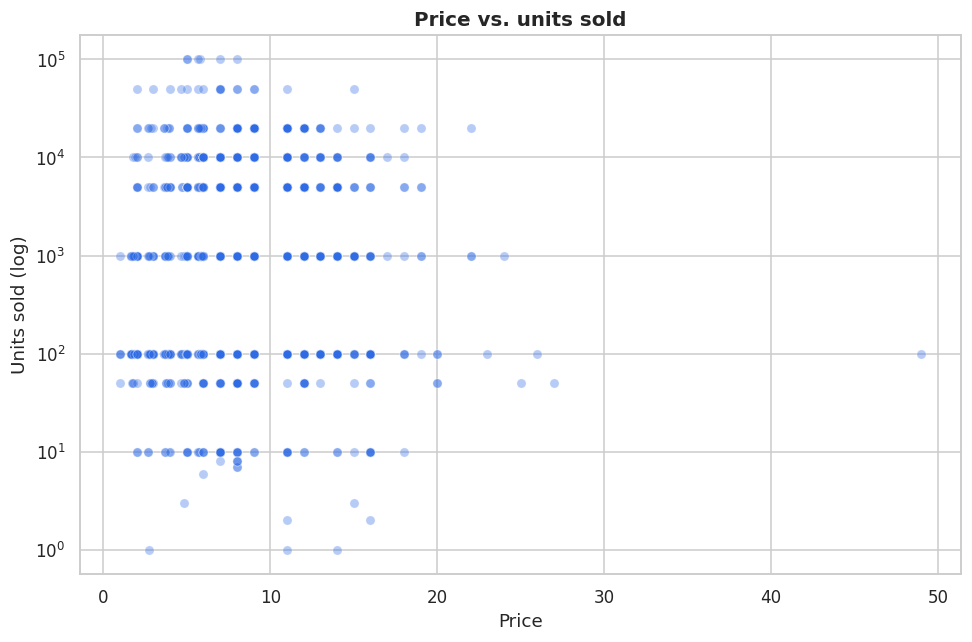

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df[df['units_sold']>0], x='price', y='units_sold', alpha=0.35, color='#2F6BE4')
plt.yscale('log')
plt.xlabel('Price'); plt.ylabel('Units sold (log)')
plt.title('Price vs. units sold', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

**Read-out:** there's no clean 'cheaper = sells more' pattern — strong sellers appear across the price range. Competing on price alone isn't the path to volume.

## Do ad boosts actually lift sales?

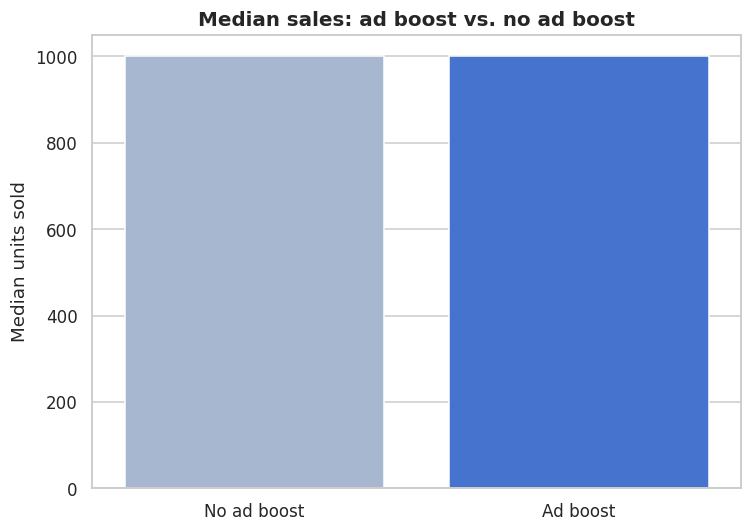

In [16]:
plt.figure(figsize=(7,5))
order=[0,1]
sns.barplot(data=df, x='uses_ad_boosts', y='units_sold', order=order,
            hue='uses_ad_boosts', legend=False,
            estimator=np.median, errorbar=None, palette=['#9FB6D6','#2F6BE4'])
plt.xticks([0,1], ['No ad boost','Ad boost'])
plt.xlabel(''); plt.ylabel('Median units sold')
plt.title('Median sales: ad boost vs. no ad boost', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

**Read-out:** the median sales of ad-boosted and non-boosted products are close — ad boosts buy *visibility*, not a reliable jump in sales.

## SPI — separating winners

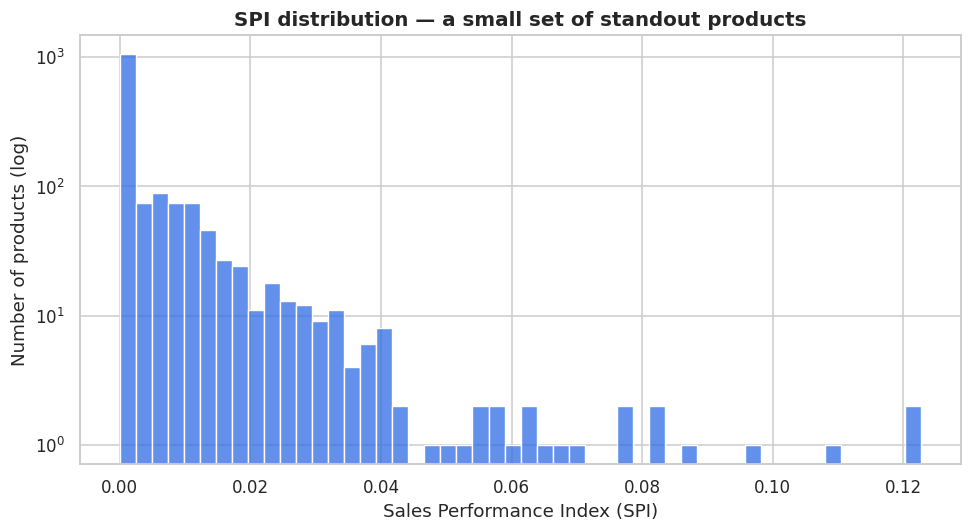

In [17]:
plt.figure(figsize=(9,5))
sns.histplot(df[df['SPI']>0]['SPI'], bins=50, color='#2F6BE4')
plt.yscale('log')
plt.xlabel('Sales Performance Index (SPI)'); plt.ylabel('Number of products (log)')
plt.title('SPI distribution — a small set of standout products', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

In [18]:
# Top 5% of products by SPI — the standouts
top_spi = df[df['SPI'] > df['SPI'].quantile(0.95)]
top_spi[['title_orig','price','units_sold','rating','rating_count','SPI']]\
    .sort_values('SPI', ascending=False).head(10)

,title_orig,price,units_sold,rating,rating_count,SPI
214,New Aeeival Women Clothing Long Sleeve Autumn Winter Ball Gown Dress Slim Fit Patchwork Casual Lace Dress Vestido De Renda,8.00,100000,3.76,11062,0.12
401,Women Lace Beach Boho Maxi Sundress Sleeveless Long Dress Party Holiday Strapless Dresses,15.00,50000,3.94,6735,0.12
1018,Women Lace Short Sleeve Long Tops Blouse Shirt Ladies Beach BOHO Mini Dress 6-16,7.00,100000,3.82,11913,0.11
92,Women Stretchy Camisole Spaghetti Strap Long Tank Top Slip Mini Dress 4Color SIZE XXL is available Now,5.77,100000,4.10,20744,0.10
1028,Women's Striped Double Up Tankini Top,11.00,50000,3.91,13488,0.09
1168,Women's Summer Sexy Sleeveless Turtleneck Mini Dress,5.67,100000,3.53,18393,0.08
251,Womens Summer Red White and Blue Chiffon Short-Sleeve T-Shirt,5.00,100000,3.98,13789,0.08
40,Sexy Women Casual Striped T-shirt Long Tops Blouse Kaftan Beach Shirt Mini Dress,9.00,50000,4.26,5359,0.08
17,2018 New Fashion Women's Tops Sexy Strappy Sleeveless Lace Crop Tops,5.00,100000,3.83,17980,0.08
952,Hot Latest Sexy Bikini Women Fashion Swimming Suit Beach Bikini with Bracket Gather NOR,9.00,50000,3.83,13198,0.07


## Conclusions

- **Trust beats price.** Review *volume* (`rating_count`) is the strongest correlate of sales; price and star-rating alone are weak. Social proof drives conversion.
- **Ad boosts buy visibility, not lasting sales** — boosted products don't out-sell others at the median, and appear across the whole performance range.
- **Growth is a reinforcing loop:** reviews → trust → conversion → more sales → more reviews. The job is to seed that loop early.
- **The SPI** highlights a small set of standout products that combine healthy price, strong ratings and real sales — useful for prioritising what to promote.

*Strategic implication: help new products accumulate credible reviews fast, rather than competing on price or relying on paid boosts.*